# Multi-Sleeve US Equities Statistical Arbitrage

Notebook reproduces all paper results using the `qstudy` [library](https://github.com/jwplatta/qstudy). It uses `qstudy` for data download, the Study pipeline, PortfolioStudy, and metrics, but all signal, conditioning, and scaler logic is inlined directly. Run top-to-bottom. Outputs written to `notebooks/out/`.

## Section 0: Imports & Configuration

In [27]:
from __future__ import annotations

import warnings
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500
from qstudy.study.PortfolioStudy import PortfolioStudy
from qstudy.study.metrics import drawdown_series, turnover
import qstudy.study.metrics as qs_metrics

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path(".").resolve()
OUT_DIR      = NOTEBOOK_DIR / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2015-01-01"
IS_END     = "2023-12-31"
COST_BPS   = 10.0
N_LONG = N_SHORT = 20
FACTORS = ["SPY", "XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLU", "XLRE", "XLB"]
SECTOR_ETFS = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLU", "XLRE", "XLB"]

GICS_TO_ETF = {
    "Technology": "XLK", "Financial Services": "XLF", "Energy": "XLE",
    "Healthcare": "XLV", "Industrials": "XLI", "Consumer Cyclical": "XLY",
    "Consumer Defensive": "XLP", "Utilities": "XLU", "Real Estate": "XLRE",
    "Basic Materials": "XLB", "Communication Services": "XLK",
}

SHORT_LABELS = {
    "monoton_120d__r21__disp_60_q30__cond__none":
        "Monotonic Momentum\n(120d, r21; low-disp scaled)",
    "zscore_rev_5_60__r10__trend_20_100__cond__residual_dispersion_high_20_q75":
        "Active-Return MR\n(z/60, r10; resid-disp gate)",
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75":
        "Residual MR\n(factor model 5d, r10; resid-disp gate)",
    "dist_mr_k3_z60__r10__cond__none":
        "Dist Pairs MR\n(k=3, z60, r10; always-on)",
    "sector_rel_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75":
        "Sector-Relative MR\n(5d, r10; resid-disp gate)",
    "resid_gap_reversion__r10__trend_50_200__cond__vol_contraction_10_60":
        "Residual Gap Reversion\n(residual gap, r10; vol contraction)",
}

BEST_SLEEVES = list(SHORT_LABELS.keys())

print(f"Output dir: {OUT_DIR}")
print(f"SP500 universe: {len(SP500)} tickers")
print(f"Sleeves: {len(BEST_SLEEVES)}")


Output dir: /Users/jplatta/repos/portfolio-research/notebooks/out
SP500 universe: 497 tickers
Sleeves: 6


## Section 1: Data Download

In [28]:
@cache
def load_universe():
    return qs.download(SP500, START_DATE, IS_END)

@cache
def load_benchmark():
    return qs.download(["SPY"], START_DATE, IS_END)

@cache
def load_factors():
    return qs.download(FACTORS, START_DATE, IS_END)

@cache
def load_sector_map() -> dict[str, str]:
    return qs.get_sector_map(SP500)

@cache
def load_sector_etf_map() -> dict[str, str]:
    sector_map = load_sector_map()
    return {t: GICS_TO_ETF.get(s, "SPY") for t, s in sector_map.items()}

@cache
def load_distance_partners() -> dict[int, dict[str, list[str]]]:
    """Top-3 nearest partners by normalised price correlation, per z-window."""
    universe = load_universe()
    log_price = universe.log_returns.cumsum()
    norm = (log_price - log_price.mean()) / log_price.std().clip(lower=1e-8)
    dist = 1 - norm.corr()
    partners = {}
    for zw in [10, 20, 60]:
        p = {}
        for ticker in dist.columns:
            p[ticker] = dist[ticker].drop(ticker).nsmallest(3).index.tolist()
        partners[zw] = p
    return partners

print("Loading IS data via qstudy...")
u = load_universe()
print(f"  Universe : {u.returns.shape[0]} days × {u.returns.shape[1]} tickers")
print(f"  Benchmark: {load_benchmark().returns.shape}")
print(f"  Factors  : {load_factors().returns.shape[1]} factors")


Loading IS data via qstudy...
  Universe : 2264 days × 461 tickers
  Benchmark: (2264, 1)
  Factors  : 10 factors


## Section 2: Signal, Conditioning & Scaler Functions

In [29]:
def _sector_returns_df(returns: pd.DataFrame, factor_returns: pd.DataFrame) -> pd.DataFrame:
    """Per-ticker sector ETF return series (same shape as returns)."""
    etf_map = load_sector_etf_map()
    out = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    for ticker in returns.columns:
        etf = etf_map.get(ticker, "SPY")
        if etf in factor_returns.columns:
            out[ticker] = factor_returns[etf].reindex(returns.index).fillna(0.0)
        else:
            out[ticker] = 0.0
    return out


def average_corr_series(returns: pd.DataFrame, window: int) -> pd.Series:
    sample = returns.dropna(axis=1, how="all").iloc[:, :50]
    if sample.shape[1] < 2:
        return pd.Series(index=returns.index, dtype=float)
    return (
        sample.rolling(window).corr()
        .groupby(level=0)
        .apply(lambda m: (m.values.sum() - len(m)) / max(len(m) * (len(m) - 1), 1))
        .reindex(returns.index)
    )


In [30]:
# NOTE: build signal functions
def make_monoton_120d():
    def monoton_120d(**cache):
        r  = cache["_active_returns"]
        mu = r.rolling(120).mean()
        same_sign = (r.gt(0) == mu.gt(0)).astype(float)
        return same_sign.rolling(120).mean() * mu.abs()
    monoton_120d.__name__ = "monoton_120d"
    return monoton_120d

def make_mr_5d():
    def mr_5d(**cache):
        return -cache["_active_returns"].rolling(5).mean()
    mr_5d.__name__ = "mr_5d"
    return mr_5d

def make_zscore_rev_5_60():
    """Z-score mean reversion: -(5d mean - 60d mean) / 60d std."""
    def zscore_rev_5_60(**cache):
        r     = cache["_active_returns"]
        mu    = r.rolling(60).mean()
        sigma = r.rolling(60).std().clip(lower=1e-8)
        return -(r.rolling(5).mean() - mu) / sigma
    zscore_rev_5_60.__name__ = "zscore_rev_5_60"
    return zscore_rev_5_60

def make_factor_model_resid_mr_5d():
    def factor_model_resid_mr_5d(**cache):
        return -cache["residual_returns"].rolling(5).mean()
    factor_model_resid_mr_5d.__name__ = "factor_model_resid_mr_5d"
    return factor_model_resid_mr_5d

def make_dist_mr(zw: int):
    """Distance-pairs MR with k=3 nearest partners and z-window=zw."""
    def dist_mr(**cache):
        r = cache["_active_returns"]
        partners = load_distance_partners()[zw]
        price = (1 + r).cumprod()
        norm  = price / price.iloc[0].clip(lower=1e-8)
        spread = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)
        for ticker in r.columns:
            peers = [p for p in partners.get(ticker, []) if p in r.columns]
            if peers:
                spread[ticker] = norm[ticker] - norm[peers].mean(axis=1)
        mu    = spread.rolling(zw).mean()
        sigma = spread.rolling(zw).std().clip(lower=1e-8)
        return -((spread - mu) / sigma).clip(-2, 2)
    dist_mr.__name__ = f"dist_mr_k3_z{zw}"
    return dist_mr

def make_sector_rel_mr_5d():
    """Sector-relative mean reversion: -(stock - sector ETF) 5d mean."""
    def sector_rel_mr_5d(**cache):
        r          = cache["_active_returns"]
        factor_ret = cache["factor_returns"]
        etf_map    = load_sector_etf_map()
        sector_df  = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)
        for ticker in r.columns:
            etf = etf_map.get(ticker, "SPY")
            sector_df[ticker] = (
                factor_ret[etf].reindex(r.index).fillna(0.0)
                if etf in factor_ret.columns else 0.0
            )
        return -(r - sector_df).rolling(5).mean()
    sector_rel_mr_5d.__name__ = "sector_rel_mr_5d"
    return sector_rel_mr_5d

def make_resid_gap_reversion():
    """ETF-factor residualized overnight gap reversal."""
    def resid_gap_reversion(**cache):
        return -cache["residual_returns"].shift(1)
    resid_gap_reversion.__name__ = "resid_gap_reversion"
    return resid_gap_reversion


In [31]:
# NOTE: Define conditioning filters. Used with Study.add_filter(fn).
# Gates: NaN the signal when the regime condition is NOT active.

def filter_residual_dispersion_high_20_q75(signal, **cache):
    resid    = cache["residual_returns"]
    disp     = resid.std(axis=1).rolling(20).mean()
    thresh   = disp.rolling(252).quantile(0.75)
    mask     = disp.gt(thresh).reindex(signal.index).fillna(False)
    return signal.where(mask, other=np.nan)
filter_residual_dispersion_high_20_q75.__name__ = "residual_dispersion_high_20_q75"

def filter_breadth_weak_40(signal, **cache):
    prices   = (1 + cache["returns"]).cumprod()
    pct_abv  = (prices > prices.rolling(200).mean()).mean(axis=1)
    mask     = pct_abv.lt(0.40).reindex(signal.index).fillna(False)
    return signal.where(mask, other=np.nan)
filter_breadth_weak_40.__name__ = "breadth_weak_40"

def filter_vol_contraction_10_60(signal, **cache):
    bm   = cache["benchmark"]
    mask = bm.rolling(10).std().lt(bm.rolling(60).std()).reindex(signal.index).fillna(False)
    return signal.where(mask, other=np.nan)
filter_vol_contraction_10_60.__name__ = "vol_contraction_10_60"

def filter_vol_expansion_10_60(signal, **cache):
    bm   = cache["benchmark"]
    mask = bm.rolling(10).std().gt(bm.rolling(60).std()).reindex(signal.index).fillna(False)
    return signal.where(mask, other=np.nan)
filter_vol_expansion_10_60.__name__ = "vol_expansion_10_60"

def filter_panic_10d_minus5(signal, **cache):
    bm   = cache["benchmark"]
    mask = bm.rolling(10).sum().lt(-0.05).reindex(signal.index).fillna(False)
    return signal.where(mask, other=np.nan)
filter_panic_10d_minus5.__name__ = "panic_10d_minus5"


In [32]:
# NOTE: define risk scalers

def equity_curve_regime_scale(positions, **cache):
    """25% exposure when equity curve < 20-day MA."""
    returns = cache["returns"]
    _tm = cache.get("_tradeable_mask")
    _lm = cache.get("_liquidity_mask")
    mask = _tm if _tm is not None else _lm
    r       = returns.where(mask) if mask is not None else returns
    raw     = (positions.shift(1) * r).sum(axis=1)
    equity  = (1 + raw).cumprod()
    scale   = pd.Series(np.where(equity > equity.rolling(20).mean(), 1.0, 0.25), index=equity.index)
    return positions.mul(scale.shift(1), axis=0)
equity_curve_regime_scale.__name__ = "equity_curve_regime_scale"


def make_trend_scaler(fast: int, slow: int, mr_style: bool = True, scale_down: float = 0.25):
    """Trend-based position scaler.

    mr_style=True  → scale_down when IN uptrend (MR families scale down in bull markets)
    mr_style=False → scale_down when NOT in uptrend (momentum scales down in bear markets)
    """
    def _trend(positions, **cache):
        bm    = cache["benchmark"]
        spy   = (1 + bm).cumprod()
        up    = spy.rolling(fast).mean().gt(spy.rolling(slow).mean()).reindex(positions.index).fillna(False)
        cond  = up if mr_style else ~up
        scale = pd.Series(np.where(cond, scale_down, 1.0), index=positions.index)
        return positions.mul(scale.shift(1), axis=0)
    _trend.__name__ = f"trend_{fast}_{slow}"
    return _trend


def make_disp_scaler(window: int, low_q: float):
    """25% when cross-sectional return dispersion < low_q percentile (rolling 252d)."""
    def _disp(positions, **cache):
        disp    = cache["returns"].std(axis=1).rolling(window).mean()
        low_disp = disp.lt(disp.rolling(252).quantile(low_q)).reindex(positions.index).fillna(False)
        scale   = pd.Series(np.where(low_disp, 0.25, 1.0), index=positions.index)
        return positions.mul(scale.shift(1), axis=0)
    _disp.__name__ = f"disp_{window}_q{int(low_q*100)}"
    return _disp


def make_crash_scaler(window: int = 10, threshold: float = 0.05):
    """25% when SPY has rebounded > threshold over window days (post-crash recovery)."""
    def _crash(positions, **cache):
        bm      = cache["benchmark"]
        rebound = bm.rolling(window).sum().gt(threshold).reindex(positions.index).fillna(False)
        scale   = pd.Series(np.where(rebound, 0.25, 1.0), index=positions.index)
        return positions.mul(scale.shift(1), axis=0)
    _crash.__name__ = f"crash_{window}_{int(threshold*100)}pct"
    return _crash


def make_breadth_scaler(threshold: float):
    """25% when pct of stocks above 200d MA < threshold."""
    def _breadth(positions, **cache):
        prices  = (1 + cache["returns"]).cumprod()
        pct_abv = (prices > prices.rolling(200).mean()).mean(axis=1)
        weak    = pct_abv.lt(threshold).reindex(positions.index).fillna(False)
        scale   = pd.Series(np.where(weak, 0.25, 1.0), index=positions.index)
        return positions.mul(scale.shift(1), axis=0)
    _breadth.__name__ = f"breadth_{int(threshold*100)}"
    return _breadth


In [33]:
# NOTE: Builds and runs one sleeve Study.
# Transaction costs are NOT applied at the sleeve level, only at the portfolio level via make_portfolio().

def run_sleeve(
    signal_fn,
    conditioning_filter,
    rebalance_every: int,
    risk_scalers: list,
    use_factor_model: bool,
    use_etf_resid: bool,
    needs_resid_cache: bool,
    universe,
    benchmark,
    factors,
) -> Study:
    builder = Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        verbose=False,
    )

    if use_factor_model:
        builder = builder.add_factor_model(
            factors=["market", "sector"],
            sector_map=load_sector_map(),
        )
    if use_factor_model or use_etf_resid or needs_resid_cache:
        builder = builder.residualize_returns()

    builder = builder.base_signal(signal_fn)

    if conditioning_filter is not None:
        builder = builder.add_filter(conditioning_filter)

    builder = (
        builder
        .add_tradeable_constraint(qs.liquidity(top_n=300))
        .rank_transform()
        .build_long_short(n_long=N_LONG, n_short=N_SHORT)
        .fully_invest()
        .scale_risk(fn=equity_curve_regime_scale)
    )

    for scaler_fn in risk_scalers:
        builder = builder.scale_risk(fn=scaler_fn)

    builder = builder.rebalance(every=rebalance_every)
    # No sleeve-level costs — applied at portfolio level only
    return builder.run()


In [34]:
# NOTE: Figure 1 sleeves (one per family, top net Sharpe)
# Each entry: (signal_fn, cond_filter, rebalance, [risk_scalers], use_factor_model, use_etf_resid, needs_resid_cache)

SLEEVE_DEFS = {
    "monoton_120d__r21__disp_60_q30__cond__none": (
        make_monoton_120d(), None, 21,
        [make_disp_scaler(60, 0.30)],
        False, False, False,
    ),
    "zscore_rev_5_60__r10__trend_20_100__cond__residual_dispersion_high_20_q75": (
        make_zscore_rev_5_60(), filter_residual_dispersion_high_20_q75, 10,
        [make_trend_scaler(20, 100, mr_style=True)],
        False, False, True,
    ),
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75": (
        make_factor_model_resid_mr_5d(), filter_residual_dispersion_high_20_q75, 10,
        [make_trend_scaler(20, 100, mr_style=True)],
        True, False, False,
    ),
    "dist_mr_k3_z60__r10__cond__none": (
        make_dist_mr(60), None, 10, [],
        False, False, False,
    ),
    "sector_rel_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75": (
        make_sector_rel_mr_5d(), filter_residual_dispersion_high_20_q75, 10,
        [make_trend_scaler(20, 100, mr_style=True)],
        False, False, True,
    ),
    "resid_gap_reversion__r10__trend_50_200__cond__vol_contraction_10_60": (
        make_resid_gap_reversion(), filter_vol_contraction_10_60, 10,
        [make_trend_scaler(50, 200, mr_style=True)],
        False, True, False,
    ),
}

# NOTE: Table 3 portfolio sleeves (8-sleeve portfolio). These are the sleeves used in the portfolio buildout table.
PORTFOLIO_DEFS = {
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75": (
        make_factor_model_resid_mr_5d(), filter_residual_dispersion_high_20_q75, 10,
        [make_trend_scaler(20, 100, mr_style=True)],
        True, False, False,
    ),
    "mr_5d__r10__trend_50_200__cond__breadth_weak_40": (
        make_mr_5d(), filter_breadth_weak_40, 10,
        [make_trend_scaler(50, 200, mr_style=True)],
        False, False, False,
    ),
    "dist_mr_k3_z20__r21__cond__vol_contraction_10_60": (
        make_dist_mr(20), filter_vol_contraction_10_60, 21, [],
        False, False, False,
    ),
    "dist_mr_k3_z60__r5__cond__vol_expansion_10_60": (
        make_dist_mr(60), filter_vol_expansion_10_60, 5, [],
        False, False, False,
    ),
    "dist_mr_k3_z60__r10__cond__none": (
        make_dist_mr(60), None, 10, [],
        False, False, False,
    ),
    "dist_mr_k3_z10__r10__cond__panic_10d_minus5": (
        make_dist_mr(10), filter_panic_10d_minus5, 10, [],
        False, False, False,
    ),
    "monoton_120d__r21__crash_10_5pct": (
        make_monoton_120d(), None, 21,
        [make_crash_scaler(10, 0.05)],
        False, False, False,
    ),
    "resid_gap_reversion__r10__breadth_40": (
        make_resid_gap_reversion(), None, 10,
        [make_breadth_scaler(0.40)],
        False, True, False,
    ),
}

# NOTE: Buildout order is core MR first, then momentum, gap-rev last
PORTFOLIO_ORDER = [
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75",
    "mr_5d__r10__trend_50_200__cond__breadth_weak_40",
    "dist_mr_k3_z20__r21__cond__vol_contraction_10_60",
    "dist_mr_k3_z60__r5__cond__vol_expansion_10_60",
    "dist_mr_k3_z60__r10__cond__none",
    "dist_mr_k3_z10__r10__cond__panic_10d_minus5",
    "monoton_120d__r21__crash_10_5pct",
    "resid_gap_reversion__r10__breadth_40",
]

PORTFOLIO_SHORT = {
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75":
        "Residual MR (high resid. disp. gate)",
    "mr_5d__r10__trend_50_200__cond__breadth_weak_40":
        "+ Active-Return MR (breadth gate)",
    "dist_mr_k3_z20__r21__cond__vol_contraction_10_60":
        "+ DPMR (z20, vol contraction gate)",
    "dist_mr_k3_z60__r5__cond__vol_expansion_10_60":
        "+ DPMR (z60, vol expansion gate)",
    "dist_mr_k3_z60__r10__cond__none":
        "+ DPMR (z60, always-on)",
    "dist_mr_k3_z10__r10__cond__panic_10d_minus5":
        "+ DPMR (z10, panic gate)",
    "monoton_120d__r21__crash_10_5pct":
        "+ Monotonic Momentum (crash-gated)",
    "resid_gap_reversion__r10__breadth_40":
        "+ Resid. Gap Reversion (breadth-gated)",
}

print(f"Figure 1 sleeves: {len(SLEEVE_DEFS)}")
print(f"Portfolio sleeves:  {len(PORTFOLIO_DEFS)}")


Figure 1 sleeves: 6
Portfolio sleeves:  8


## Run All 8 Sleeves for In-Sample Period

In [35]:
print(f"Running {len(BEST_SLEEVES)} sleeves on IS data ({START_DATE} to {IS_END}) ...")
sleeve_studies: dict[str, Study] = {}

for label in BEST_SLEEVES:
    sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = SLEEVE_DEFS[label]
    short = SHORT_LABELS[label].split("\n")[0]
    print(f"  {short} ...", end=" ", flush=True)
    sleeve_studies[label] = run_sleeve(
        signal_fn=sig_fn,
        conditioning_filter=cond_filter,
        rebalance_every=rebal,
        risk_scalers=scalers,
        use_factor_model=use_fm,
        use_etf_resid=use_etf,
        needs_resid_cache=needs_resid,
        universe=load_universe(),
        benchmark=load_benchmark(),
        factors=load_factors(),
    )
    m = sleeve_studies[label].metrics_dict()
    print(f"sharpe={m.get('sharpe', float('nan')):.2f}")

print("Done")


Running 6 sleeves on IS data (2015-01-01 to 2023-12-31) ...
  Monotonic Momentum ... sharpe=0.90
  Active-Return MR ... Using factors for residuals...
sharpe=1.43
  Residual MR ... Using barra-lite factor model for residuals...
sharpe=1.19
  Dist Pairs MR ... sharpe=1.54
  Sector-Relative MR ... Using factors for residuals...
sharpe=1.01
  Residual Gap Reversion ... Using factors for residuals...
sharpe=1.10
Done


In [36]:
rows = []
for label in BEST_SLEEVES:
    m = sleeve_studies[label].metrics_dict()
    rows.append({
        "Sleeve":     SHORT_LABELS[label],
        "Sharpe":     round(m.get("sharpe", float("nan")), 2),
        "Ann Return": f"{m.get('ann_return', 0):.1%}",
        "Ann Vol":    f"{m.get('ann_vol', 0):.1%}",
        "Max DD":     f"{m.get('max_drawdown', 0):.1%}",
        "Avg TO":     f"{m.get('avg_daily_turnover', 0):.3f}",
        "BM Corr":    round(m.get("benchmark_corr", float("nan")), 3),
    })

table_is = pd.DataFrame(rows).set_index("Sleeve")
display(table_is)


,Sharpe,Ann Return,Ann Vol,Max DD,Avg TO,BM Corr
Sleeve,,,,,,
"Monotonic Momentum\n(120d, r21; low-disp scaled)",0.90,6.3%,7.1%,-10.1%,0.547,0.253
"Active-Return MR\n(z/60, r10; resid-disp gate)",1.43,4.6%,3.2%,-3.2%,0.213,0.144
"Residual MR\n(factor model 5d, r10; resid-disp gate)",1.19,4.7%,3.9%,-4.1%,0.181,0.093
"Dist Pairs MR\n(k=3, z60, r10; always-on)",1.54,11.1%,7.0%,-9.6%,0.625,-0.179
"Sector-Relative MR\n(5d, r10; resid-disp gate)",1.01,4.2%,4.1%,-5.9%,0.205,0.018
"Residual Gap Reversion\n(residual gap, r10; vol contraction)",1.10,3.8%,3.4%,-3.6%,1.064,0.047


## Figure 1: Sleeve Return Correlation Heatmap

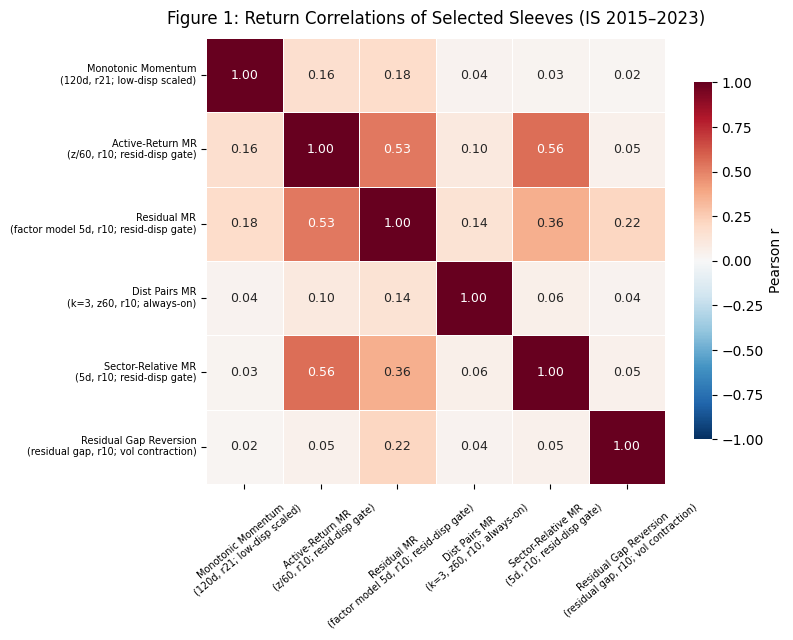

Saved figure1_sleeve_correlation_heatmap.png


In [37]:
sleeve_ret_df = pd.DataFrame({
    SHORT_LABELS[l]: sleeve_studies[l].cache["portfolio_returns"]
    for l in BEST_SLEEVES
}).dropna()

corr = sleeve_ret_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 9}, ax=ax,
)
ax.set_title("Figure 1: Return Correlations of Selected Sleeves (IS 2015–2023)", pad=10)
ax.tick_params(axis="x", rotation=40, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / "figure1_sleeve_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure1_sleeve_correlation_heatmap.png")

## Table 3: Sleeve-by-Sleeve Portfolio Buildout

Uses equal-vol weighting with transaction costs applied at the portfolio level.

In [ ]:
print("Running 8 sleeves for Table 3 ...")
portfolio_studies: dict[str, Study] = {}

for label in PORTFOLIO_ORDER:
    sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = PORTFOLIO_DEFS[label]
    short = PORTFOLIO_SHORT[label]
    print(f"  {short} ...", end=" ", flush=True)
    portfolio_studies[label] = run_sleeve(
        signal_fn=sig_fn,
        conditioning_filter=cond_filter,
        rebalance_every=rebal,
        risk_scalers=scalers,
        use_factor_model=use_fm,
        use_etf_resid=use_etf,
        needs_resid_cache=needs_resid,
        universe=load_universe(),
        benchmark=load_benchmark(),
        factors=load_factors(),
    )
    m = portfolio_studies[label].metrics_dict()
    print(f"net_sharpe={m.get('net_sharpe', m.get('sharpe', float('nan'))):.3f}")

print("Done")


In [ ]:
def make_portfolio(
    sleeve_labels: list[str],
    studies: dict[str, Study],
    weighting: str = "equal_vol",
    cost_bps: float = COST_BPS,
    vol_target: float | None = None,
    name: str = "Portfolio",
) -> PortfolioStudy:
    port = PortfolioStudy(
        strategies=[studies[l] for l in sleeve_labels],
        universe=load_universe(),
        benchmark=load_benchmark(),
        name=name,
        cost_bps=cost_bps,
        verbose=False,
    )
    weighting_fns = {
        "equal":        port.weight_equal,
        "equal_vol":    port.weight_equal_vol,
        "equal_sharpe": port.weight_equal_sharpe,
        "optimal":      port.weight_optimal,
    }
    port = weighting_fns[weighting]()
    if vol_target is not None:
        port = port.leverage(vol_target=vol_target)  # leverage first
    port = port.with_transaction_costs(cost_bps)     # then costs on levered notional
    return port.run()


In [ ]:
buildout_rows  = []
current_labels = []

for i, label in enumerate(PORTFOLIO_ORDER):
    current_labels.append(label)
    port = make_portfolio(current_labels, portfolio_studies, weighting="equal")
    m    = port.metrics_dict()
    buildout_rows.append({
        "Step":         i + 1,
        "Sleeve Added": PORTFOLIO_SHORT[label],
        "Sleeves":      len(current_labels),
        "Net SR":       round(m.get("net_sharpe", m.get("sharpe", float("nan"))), 3),
        "Gross SR":     round(m.get("gross_sharpe", float("nan")), 3),
        "Turnover":     f"{m.get('avg_daily_turnover', 0):.3%}",
        "Max DD":       f"{m.get('max_drawdown', 0):.3%}",
    })
    print(f"  Step {i+1}: net_sharpe={buildout_rows[-1]['Net SR']:.3f}")

table3 = pd.DataFrame(buildout_rows).set_index("Step")
table3.to_csv(OUT_DIR / "table3_portfolio_buildout.csv")
display(table3)
print("Saved table3_portfolio_buildout.csv")


## Figure 2: Robustness Heatmap

6 portfolio variants × 4 weighting schemes.

In [ ]:
WEIGHTING_SCHEMES = ["equal", "equal_vol", "equal_sharpe", "optimal"]
CORE = [
    "factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75",
    "mr_5d__r10__trend_50_200__cond__breadth_weak_40",
    "dist_mr_k3_z20__r21__cond__vol_contraction_10_60",
    "dist_mr_k3_z60__r5__cond__vol_expansion_10_60",
    "dist_mr_k3_z60__r10__cond__none",
    "dist_mr_k3_z10__r10__cond__panic_10d_minus5",
]
EXT_MON  = "monoton_120d__r21__crash_10_5pct"
EXT_EV40 = "resid_gap_reversion__r10__breadth_40"
EXT_EV60 = "resid_gap_reversion__r10__breadth_60"
DROP_MED  = "dist_mr_k3_z60__r10__cond__none"
DROP_FAST = "dist_mr_k3_z10__r10__cond__panic_10d_minus5"

VARIANTS = {
    "Core":                          CORE,
    "Core + MON Crash":              CORE + [EXT_MON],
    "Core + MON Crash + EV40":       CORE + [EXT_MON, EXT_EV40],
    "Core + MON Crash + EV60":       CORE + [EXT_MON, EXT_EV60],
    "Remove Medium DPMR\n+ MON Crash + EV40":
        [l for l in CORE if l != DROP_MED]  + [EXT_MON, EXT_EV40],
    "Remove Fast DPMR\n+ MON Crash + EV40":
        [l for l in CORE if l != DROP_FAST] + [EXT_MON, EXT_EV40],
}

# All studies needed across all variants
all_needed = list(dict.fromkeys(
    l for labels in VARIANTS.values() for l in labels
))

# Run any sleeve not already in portfolio_studies
rob_studies = dict(portfolio_studies)  # already have PORTFOLIO_ORDER sleeves

# EV60 needs to be run separately — not in PORTFOLIO_DEFS
if EXT_EV60 not in rob_studies:
    print(f"Running {EXT_EV60} ...", end=" ", flush=True)
    rob_studies[EXT_EV60] = run_sleeve(
        signal_fn=make_resid_gap_reversion(),
        conditioning_filter=None,
        rebalance_every=10,
        risk_scalers=[make_breadth_scaler(0.60)],
        use_factor_model=False,
        use_etf_resid=True,
        needs_resid_cache=False,
        universe=load_universe(),
        benchmark=load_benchmark(),
        factors=load_factors(),
    )
    m = rob_studies[EXT_EV60].metrics_dict()
    print(f"net_sharpe={m.get('net_sharpe', m.get('sharpe')):.3f}")

rob_rows = []
for variant_name, labels in VARIANTS.items():
    for w in WEIGHTING_SCHEMES:
        print(f"  {variant_name.split(chr(10))[0]} [{w}] ...", end=" ", flush=True)
        port = make_portfolio(labels, rob_studies, weighting=w)
        m    = port.metrics_dict()
        net  = m.get("net_sharpe", m.get("sharpe", float("nan")))
        rob_rows.append({"Variant": variant_name, "Weighting": w, "Net Sharpe": net})
        print(f"{net:.3f}")

rob_df  = pd.DataFrame(rob_rows)
rob_mat = rob_df.pivot(index="Variant", columns="Weighting", values="Net Sharpe")
rob_mat = rob_mat.loc[list(VARIANTS.keys()), WEIGHTING_SCHEMES]

fig, ax = plt.subplots(figsize=(6.8, 5))
sns.heatmap(
    rob_mat.astype(float), annot=True, fmt=".3f", cmap="YlGnBu",
    linewidths=0.4, cbar_kws={"shrink": 0.85, "label": "Net Sharpe"},
    annot_kws={"size": 8}, ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=45, labelsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / "figure2_robustness_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure2_robustness_heatmap.png")


## Table 5: Equal-Vol Sleeve Attribution

In [ ]:
# NOTE: Table 5 uses the 8-sleeve equal-vol portfolio
ret_df = pd.DataFrame({
    l: portfolio_studies[l].cache["portfolio_returns"] for l in PORTFOLIO_ORDER
}).dropna()

vol      = ret_df.std()
inv_vol  = 1 / vol.clip(lower=1e-8)
ev_wts   = inv_vol / inv_vol.sum()

cov      = ret_df.cov()
cov_w    = cov.dot(ev_wts)
port_var = float(ev_wts @ cov_w)
port_mu  = float(ev_wts @ ret_df.mean())

var_contrib = ev_wts * cov_w / port_var if port_var > 0 else ev_wts * float("nan")
ret_contrib = (ev_wts * ret_df.mean()) / port_mu if abs(port_mu) > 1e-14 else ev_wts * float("nan")

to_by_sleeve = {
    l: float(turnover(portfolio_studies[l].cache["positions"]).mean())
    for l in PORTFOLIO_ORDER
}
wt_to      = ev_wts * pd.Series(to_by_sleeve)
to_denom   = float(wt_to.sum())
to_contrib = wt_to / to_denom if abs(to_denom) > 1e-12 else wt_to * float("nan")

# NOTE: Sort by variance contribution descending
attr_rows = []
for label in PORTFOLIO_ORDER:
    m = portfolio_studies[label].metrics_dict()
    attr_rows.append({
        "Sleeve":         PORTFOLIO_SHORT[label].lstrip("+ "),
        "Weight":         f"{float(ev_wts[label]):.1%}",
        "Net SR":         round(m.get("net_sharpe", m.get("sharpe", float("nan"))), 3),
        "Ret. Contrib.":  f"{float(ret_contrib[label]):.1%}",
        "Var. Contrib.":  f"{float(var_contrib[label]):.1%}",
        "Efficiency":     round(float(ret_contrib[label] / var_contrib[label]), 3)
                          if abs(float(var_contrib[label])) > 1e-14 else float("nan"),
        "Turn. Contrib.": f"{float(to_contrib[label]):.1%}",
    })

table5 = pd.DataFrame(attr_rows).set_index("Sleeve")
table5.to_csv(OUT_DIR / "table5_sleeve_attribution.csv")
display(table5)
print("Saved table5_sleeve_attribution.csv")


## Figure 3: Transaction Cost Sensitivity

In [ ]:
COST_VALS = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 25]

cost_rows = []
for c in COST_VALS:
    print(f"  Portfolio @ {c} bps ...", end=" ", flush=True)
    port = make_portfolio(PORTFOLIO_ORDER, portfolio_studies, weighting="equal", cost_bps=c)
    m    = port.metrics_dict()
    net  = m.get("net_sharpe", m.get("sharpe", float("nan")))
    cost_rows.append({"series": "Portfolio", "cost_bps": c, "net_sharpe": net})
    print(f"{net:.2f}")

    for label in PORTFOLIO_ORDER:
        sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = PORTFOLIO_DEFS[label]
        s = run_sleeve(
            signal_fn=sig_fn, conditioning_filter=cond_filter,
            rebalance_every=rebal, risk_scalers=scalers,
            use_factor_model=use_fm, use_etf_resid=use_etf,
            needs_resid_cache=needs_resid,
            universe=load_universe(), benchmark=load_benchmark(), factors=load_factors(),
        )
        _g = s.cache.get("gross_portfolio_returns")
        gross = _g if _g is not None else s.cache["portfolio_returns"]
        to    = turnover(s.cache["positions"]).reindex(gross.index).fillna(0.0)
        net_ret = gross - to * c / 10_000
        net_s = float(net_ret.mean() / net_ret.std() * np.sqrt(252)) if net_ret.std() > 0 else float("nan")
        cost_rows.append({"series": PORTFOLIO_SHORT[label].lstrip("+ "), "cost_bps": c, "net_sharpe": net_s})

df_cost = pd.DataFrame(cost_rows)
df_cost.to_csv(OUT_DIR / "cost_sensitivity_data.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for series_name, sub in df_cost.groupby("series", sort=False):
    lw = 2.0 if series_name == "Portfolio" else 0.9
    ls = "-" if series_name == "Portfolio" else "--"
    ax.plot(sub["cost_bps"], sub["net_sharpe"], lw=lw, ls=ls, marker="o", ms=3, label=series_name)
ax.axvline(10, color="black", ls=":", lw=1.2, alpha=0.7)
ax.set_xlabel("Transaction Cost (bps)")
ax.set_ylabel("Net Sharpe Ratio")
ax.set_title("Figure 3: Net Sharpe vs Transaction Cost (IS 2015–2023)", pad=10)
ax.legend(fontsize=7, ncol=2, loc="lower left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "figure3_cost_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure3_cost_sensitivity.png")


## Figure 4: Target-Vol Equity Curves

In [ ]:
TV_CONFIGS = [
    (None,  "Unlevered",      "black"),
    (0.05,  "5% Target Vol",  "steelblue"),
    (0.10,  "10% Target Vol", "#2ca02c"),    # green — matches report
    (0.15,  "15% Target Vol", "darkorange"), # orange — matches report
]

tv_results = {}
for tv, label, _ in TV_CONFIGS:
    print(f"  {label} ...", end=" ", flush=True)
    tv_results[label] = make_portfolio(
        PORTFOLIO_ORDER, portfolio_studies, weighting="equal_vol", vol_target=tv
    )
    m = tv_results[label].metrics_dict()
    print(f"sharpe={m.get('net_sharpe', m.get('sharpe')):.2f}")

bm_ret = load_benchmark().returns["SPY"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.2, 6.6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})

for tv, label, color in TV_CONFIGS:
    ret = tv_results[label].cache["portfolio_returns"]
    eq  = (1 + ret).cumprod()
    ax1.plot(eq.index, eq, label=label, color=color, lw=1.0, alpha=0.85)
    mdd = float(drawdown_series(ret).min())
    ax2.plot(eq.index, drawdown_series(ret), color=color, lw=1.0, alpha=0.5,
             label=f"{label} ({mdd:.1%})")

bm_eq = (1 + bm_ret).cumprod().reindex(eq.index)
ax1.plot(bm_eq.index, bm_eq, color="lightgray", lw=1.0, label="Benchmark")

ax1.set_ylabel("Equity")
ax1.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax1.grid(True, alpha=0.25)
ax1.set_title("Figure 4: Equity curves at different target volatility levels.", pad=10)

ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left", fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / "figure4_target_vol_curves.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure4_target_vol_curves.png")


## Table 7 + Figure 5: Full History Out-of-Sample Results

Extended window: 2015-01-01 through 2026-04-30. OOS split: 2024-01-01.

In [ ]:
OOS_START = "2015-01-01"
OOS_END   = "2026-04-30"
OOS_SPLIT = pd.Timestamp("2024-01-01")

print(f"Downloading extended data ({OOS_START} to {OOS_END}) ...")
oos_universe  = qs.download(list(SP500), OOS_START, OOS_END)
oos_benchmark = qs.download(["SPY"], OOS_START, OOS_END)
oos_factors   = qs.download(FACTORS, OOS_START, OOS_END)
print(f"  Universe: {oos_universe.returns.shape}")

# NOTE: Distance partners are computed on in-sample data only (2015-2023).
# The script's load_distance_partners() uses START_DATE..END_DATE = 2015-2023
# and does NOT recompute on the extended window.
print("Using IS-period distance partners (computed on 2015-2023 data).")
oos_partners = load_distance_partners()  # already cached from IS period
print("Done.")


In [ ]:
# NOTE: Re-create dist_mr signal functions that close over in-sample distance partners
def make_dist_mr_oos(zw: int):
    partners = oos_partners[zw]
    def dist_mr(**cache):
        r      = cache["_active_returns"]
        price  = (1 + r).cumprod()
        norm_p = price / price.iloc[0].clip(lower=1e-8)
        spread = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)
        for ticker in r.columns:
            peers = [p for p in partners.get(ticker, []) if p in r.columns]
            if peers:
                spread[ticker] = norm_p[ticker] - norm_p[peers].mean(axis=1)
        mu    = spread.rolling(zw).mean()
        sigma = spread.rolling(zw).std().clip(lower=1e-8)
        return -((spread - mu) / sigma).clip(-2, 2)
    dist_mr.__name__ = f"dist_mr_k3_z{zw}"
    return dist_mr

# NOTE: out-of-sample defs. Same as PORTFOLIO_DEFS but dist_mr signals use in-sample distance partners
OOS_PORTFOLIO_DEFS = dict(PORTFOLIO_DEFS)
OOS_PORTFOLIO_DEFS["dist_mr_k3_z20__r21__cond__vol_contraction_10_60"] = (
    make_dist_mr_oos(20), filter_vol_contraction_10_60, 21, [], False, False, False)
OOS_PORTFOLIO_DEFS["dist_mr_k3_z60__r5__cond__vol_expansion_10_60"] = (
    make_dist_mr_oos(60), filter_vol_expansion_10_60, 5, [], False, False, False)
OOS_PORTFOLIO_DEFS["dist_mr_k3_z60__r10__cond__none"] = (
    make_dist_mr_oos(60), None, 10, [], False, False, False)
OOS_PORTFOLIO_DEFS["dist_mr_k3_z10__r10__cond__panic_10d_minus5"] = (
    make_dist_mr_oos(10), filter_panic_10d_minus5, 10, [], False, False, False)


In [ ]:
print("Running 8 sleeves on full data (2015–2026) ...")
oos_portfolio_studies: dict[str, Study] = {}

for label in PORTFOLIO_ORDER:
    sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = OOS_PORTFOLIO_DEFS[label]
    short = PORTFOLIO_SHORT[label]
    print(f"  {short} ...", end=" ", flush=True)
    oos_portfolio_studies[label] = run_sleeve(
        signal_fn=sig_fn,
        conditioning_filter=cond_filter,
        rebalance_every=rebal,
        risk_scalers=scalers,
        use_factor_model=use_fm,
        use_etf_resid=use_etf,
        needs_resid_cache=needs_resid,
        universe=oos_universe,
        benchmark=oos_benchmark,
        factors=oos_factors,
    )
    m = oos_portfolio_studies[label].metrics_dict()
    print(f"sharpe={m.get('sharpe', float('nan')):.2f}")

print("Done.")


In [ ]:
def make_oos_portfolio(
    sleeve_labels, studies, weighting="equal_vol", cost_bps=COST_BPS,
    vol_target=None, name="OOS Portfolio"
):
    port = PortfolioStudy(
        strategies=[studies[l] for l in sleeve_labels],
        universe=oos_universe,
        benchmark=oos_benchmark,
        name=name, cost_bps=cost_bps, verbose=False,
    )
    weighting_fns = {
        "equal":        port.weight_equal,
        "equal_vol":    port.weight_equal_vol,
        "equal_sharpe": port.weight_equal_sharpe,
        "optimal":      port.weight_optimal,
    }
    port = weighting_fns[weighting]()
    if vol_target is not None:
        port = port.leverage(vol_target=vol_target)  # leverage first
    port = port.with_transaction_costs(cost_bps)     # then costs on levered notional
    return port.run()

# NOTE: Equal-vol weights calibrated on in-sample returns only
oos_ret_df = pd.DataFrame({l: oos_portfolio_studies[l].cache["portfolio_returns"] for l in PORTFOLIO_ORDER})
is_vol     = oos_ret_df[oos_ret_df.index < OOS_SPLIT].std()
inv_vol_is = 1 / is_vol.clip(lower=1e-8)
oos_ev_wts = inv_vol_is / inv_vol_is.sum()

print("IS-calibrated equal-vol weights:")
for l in PORTFOLIO_ORDER:
    print(f"  {PORTFOLIO_SHORT[l]:<45}: {oos_ev_wts[l]:.3f}")

print("\nBuilding full-history portfolio (equal_vol, 10% vol target)...")
oos_port_vt10 = make_oos_portfolio(
    PORTFOLIO_ORDER, oos_portfolio_studies, weighting="equal_vol",
    vol_target=0.10, name="Portfolio EV 10%vol"
)
m_oos = oos_port_vt10.metrics_dict()
net_full_vt10 = oos_port_vt10.cache["portfolio_returns"]
print(f"Full-history net Sharpe: {m_oos.get('net_sharpe', m_oos.get('sharpe')):.3f}")


In [ ]:
bm_oos_ret = oos_benchmark.returns["SPY"]

# NOTE: Build both unlevered and 10% vol-target portfolios
print("Building unlevered portfolio...")
oos_port_unlev = make_oos_portfolio(
    PORTFOLIO_ORDER, oos_portfolio_studies, weighting="equal_vol",
    vol_target=None, name="Portfolio EV Unlevered"
)
net_unlev = oos_port_unlev.cache["portfolio_returns"]

print("Building 10% vol-target portfolio...")
oos_port_vt10 = make_oos_portfolio(
    PORTFOLIO_ORDER, oos_portfolio_studies, weighting="equal_vol",
    vol_target=0.10, name="Portfolio EV 10%vol"
)
net_full_vt10 = oos_port_vt10.cache["portfolio_returns"]

m_oos = oos_port_vt10.metrics_dict()
print(f"Full-history net Sharpe (10% vol): {m_oos.get('net_sharpe', m_oos.get('sharpe')):.3f}")

# NOTE: Annual table. Paper shows Lev. Vol = 10.0% as the vol target label, not realized annual vol.
annual_rows = []
for year in sorted(net_full_vt10.index.year.unique()):
    lev_yr = net_full_vt10[net_full_vt10.index.year == year]
    bm_yr  = bm_oos_ret.reindex(lev_yr.index)
    if len(lev_yr) < 20:
        continue
    s = qs_metrics.summary(lev_yr)
    bm_ret_yr = float((1 + bm_yr).prod() - 1)
    annual_rows.append({
        "Year":        year,
        "Period":      "OOS" if year >= OOS_SPLIT.year else "IS",
        "Lev. Ret.":   f"{s['ann_return']:.1%}",
        "Lev. SR":     round(s["sharpe"], 3),
        "Lev. Vol":    "10.0%",   # target vol; actual realized vol varies by year
        "Lev. Max DD": f"{s['max_drawdown']:.1%}",
        "SPY Ret.":    f"{bm_ret_yr:.1%}",
    })

table7 = pd.DataFrame(annual_rows).set_index("Year")
table7.to_csv(OUT_DIR / "table7_annual_performance.csv")
display(table7)
print("Saved table7_annual_performance.csv")


In [ ]:
ROLLING_WINDOW = 90

unlev_eq  = (1 + net_unlev.fillna(0)).cumprod()
lev_eq    = (1 + net_full_vt10.fillna(0)).cumprod()
bm_eq_oos = (1 + bm_oos_ret.fillna(0)).cumprod().reindex(lev_eq.index)

def rolling_sharpe(ret, window):
    return ret.rolling(window).apply(
        lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else 0, raw=True
    )

fig, axes = plt.subplots(3, 1, figsize=(8.6, 7.6), sharex=True,
                          gridspec_kw={"height_ratios": [3, 2, 2]})

# NOTE: equity curves
ax = axes[0]
ax.plot(unlev_eq.index,   unlev_eq,   color="black",    lw=1.0, label="Unlevered")
ax.plot(lev_eq.index,     lev_eq,     color="#2ca02c",  lw=1.0, label="Levered 10% Target Vol")
ax.plot(bm_eq_oos.index,  bm_eq_oos,  color="lightgray", lw=1.0, ls="--", label="Benchmark", alpha=0.9)
ax.axvline(OOS_SPLIT, color="gray", ls="--", lw=1.2)
ax.set_ylabel("Equity")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.25)

# NOTE: drawdowns
ax = axes[1]
unlev_dd = drawdown_series(net_unlev)
lev_dd   = drawdown_series(net_full_vt10)
ax.plot(unlev_dd.index, unlev_dd, color="black",   lw=1.0, alpha=0.75, label="Unlevered")
ax.plot(lev_dd.index,   lev_dd,   color="#2ca02c", lw=1.0, alpha=0.75, label="Levered 10% Target Vol")
ax.axvline(OOS_SPLIT, color="gray", ls="--", lw=1.0)
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.25)

# NOTE: rolling sharpe graph
ax = axes[2]
ax.plot(rolling_sharpe(net_unlev, ROLLING_WINDOW).index,
        rolling_sharpe(net_unlev, ROLLING_WINDOW),
        color="black", lw=0.9, label="Unlevered")
ax.plot(rolling_sharpe(net_full_vt10, ROLLING_WINDOW).index,
        rolling_sharpe(net_full_vt10, ROLLING_WINDOW),
        color="#2ca02c", lw=0.9, label="Levered 10% Target Vol")
ax.axhline(0, color="gray", lw=0.6)
ax.axvline(OOS_SPLIT, color="gray", ls="--", lw=1.0)
ax.set_ylabel("Rolling Sharpe (90d)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / "figure5_oos_summary.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure5_oos_summary.png")


In [ ]:
print("\nOutput files:")
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<55} {f.stat().st_size/1024:6.1f} KB")
